In [346]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from scipy import stats
from scipy.special import erfcinv
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Initialization

In [347]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\vis_test (caprese) results"
    elif sys.platform == "darwin": # mac
        dir = "/Volumes/Coolens_Research/Isaac/Experiments/vis_test (caprese) results"
    else:
        raise ValueError("Unable to get directory.")

    return dir

def import_dat(boundary = True):
    dir = get_dir()
    keys = ["depth_df", "time_df", "conc_df"]
    files = ["vis_x.csv", "vis_time.csv", "vis_conc_xt.csv"]
    if boundary:
        folder = os.path.join(dir, "boundary_true")
    else:
        folder = os.path.join(dir, "boundary_false")

    folders = {k: os.path.join(folder, v) for k, v in zip(keys, files)}
    out = {k: pd.read_csv(folders[k], dtype = float) for k in keys}

    return out

In [348]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[:30]
depth = depth - np.nanmin(depth)
conc = conc[:, :30]

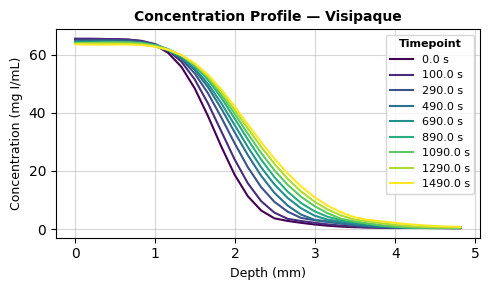

In [349]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

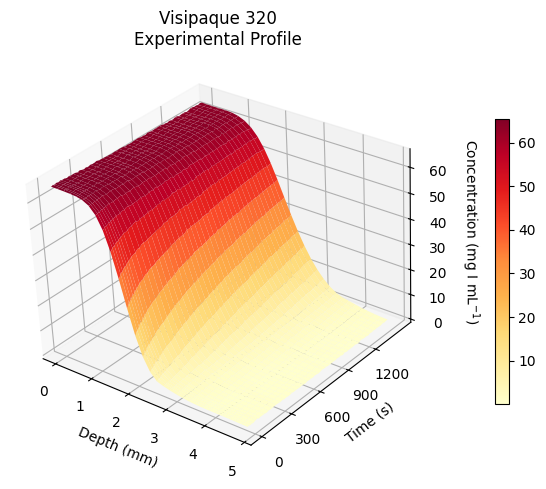

In [350]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# ICD Method

In [351]:
def icd_method(c_null, conc, time):
    try:
        t_front = np.sqrt(time)
        x_front = []
        cs_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        n = len(x_front)

        slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - marg_of_err
        slope_upper = slope + marg_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2"            : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [352]:
c_null_list = [10, 15, 20, 30]
icd_results = [icd_method(c_null, conc, time) for c_null in c_null_list]
for r in icd_results:
    print(f"{r["c_null"]} mg I/mL: {r["d"]:.2e} [{r["ci_d"][0]:.2e}, {r["ci_d"][1]:.2e}] mm2/s (r2 = {r["r2"]:.3f})")

10 mg I/mL: 1.41e-04 [1.34e-04, 1.47e-04] mm2/s (r2 = 0.990)
15 mg I/mL: 1.51e-04 [1.45e-04, 1.57e-04] mm2/s (r2 = 0.991)
20 mg I/mL: 1.63e-04 [1.57e-04, 1.69e-04] mm2/s (r2 = 0.993)
30 mg I/mL: 1.99e-04 [1.93e-04, 2.04e-04] mm2/s (r2 = 0.996)


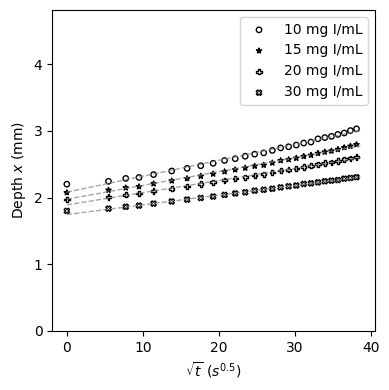

In [353]:
fig, ax = plt.subplots(figsize = (4, 4))
cats = [str(c) + " mg I /mL" for c in c_null_list]
markers = ["o", "*", "P", "X"]

for i, r in enumerate(icd_results):
        t_front = r["t_0.5"]
        x_front = r["iso_front"]
        c_null = r["c_null"]
        intercept = r["intercept"]
        slope = r["slope"]

        ax.scatter(t_front[::3], x_front[::3], 
                marker = markers[i], 
                edgecolors = "black", 
                facecolors = "none", 
                s  = 15,
                label = f"{c_null} mg I/mL")
        ax.set_xlabel(f"$\\sqrt{{t}}$ ($s^{{0.5}}$)")
        ax.set_ylabel(f"Depth $x$ (mm)")

        # plot regression line
        x_reg = np.linspace(0, np.nanmax(t_front), len(t_front))
        y_reg = slope * x_reg + intercept
        ax.plot(x_reg, y_reg, 
                linestyle = "--",
                c = "grey",
                alpha = 0.7,
                linewidth = 1)
ax.set_ylim(0, np.nanmax(depth))
plt.legend()  
plt.tight_layout()
plt.show()

# No Manual Boundary

In [354]:
# No boundary, so fitting with x0
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs.append(cfg)

In [355]:
results_x0 = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results_x0.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


# With Manual Boundary

In [356]:
dat = import_dat(boundary = True)

conc_b, depth_b, time_b = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth_b = depth_b.flatten()
time_b = time_b.flatten()

depth_b = depth_b[:30]
conc_b = conc_b[:, :30]
time_b = time_b

In [357]:
# No boundary, so fitting with x0
configs_b = []
cs_exp = np.nanmean(conc_b[:, 0])
d_mode = "global"

for fit_x0 in [False]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp
            )
            configs_b.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (0, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode
            )
            configs_b.append(cfg)

In [358]:
results_semi = []
with alive_bar(len(configs_b), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_b:
        result = fitting.fit_diffusion(conc_b, depth_b, time_b, cfg)
        results_semi.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [359]:
def sim_residual(d, cs, conc, time, depth, x0 = 0):
    semi_inf = models.semi_infinite
    conc_sim = np.empty_like(conc)

    for i, ti in enumerate(time):
        if ti == 0:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, 0.001)
        else:
            conc_sim[i, :] = semi_inf(depth, x0, d, cs, ti)

    n = conc.size
    p = 1

    residuals = (conc - conc_sim) / conc * 100
    return residuals

In [378]:
results_combined = results_x0 + results_semi
depth_combined = [depth] + [depth] + [depth_b] + [depth_b]
time_combined = [time] + [time] + [time_b] + [time_b]
conc_combined = [conc] + [conc] + [conc_b] + [conc_b]
titles_combined = [f"Semi-infinite with $x_0$", 
                   f"Semi-infinite with $x_0$ (Fixed C$_s$)",
                   f"Manually Selected Boundary",
                   f"Manually Selected Boundary (Fixed C$_s$)"
                   ]
residuals = []

for r, conc, depth, time in zip(results_combined, conc_combined, depth_combined, time_combined):
    d = r.d_global
    cs = cs_exp
    x0 = 0 if r.x0_global is None else r.x0_global

    res = sim_residual(d, cs, conc, time, depth, x0)
    residuals.append(res)


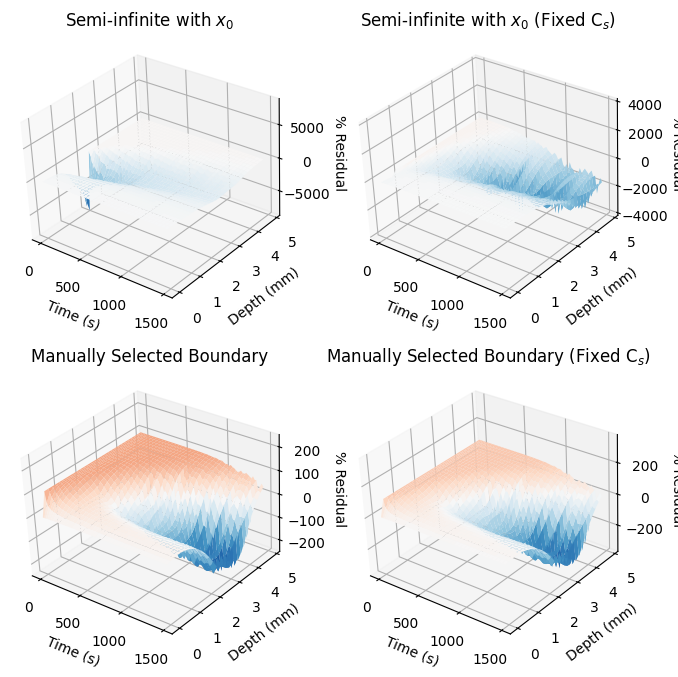

In [406]:
import matplotlib.colors as colors
fig, ax = plt.subplots(2, 2, subplot_kw = {"projection": "3d"}, figsize = (8, 8))

ax = ax.flatten()
#max_val = np.nanmax(abs(np.concatenate(residuals)))
#norm = colors.TwoSlopeNorm(vcenter = 0.0, vmin = -max_val, vmax = max_val)

for i, res in enumerate(residuals):
    depth_mesh, time_mesh = np.meshgrid(depth_combined[i], time_combined[i])
    norm = colors.TwoSlopeNorm(vcenter = 0.0,
                               vmin = -np.nanmax(abs(res)),
                               vmax = np.nanmax(abs(res)))
    surf = ax[i].plot_surface(time_mesh, depth_mesh, res,
                              linewidth = 0, cmap = "RdBu_r",
                              norm = norm)
    ax[i].view_init(elev = 30, azim = -50, roll = 3)
    ax[i].set_ylabel("Depth (mm)")
    ax[i].set_xlabel("Time (s)")
    ax[i].set_zlabel("% Residual")
    ax[i].set_zlim(-np.nanmax(abs(res)), np.nanmax(abs(res)))
    ax[i].set_title(titles_combined[i])

plt.show()

In [385]:
residuals[0].max()

np.float64(100.0)

In [362]:
[print(f"{title}: " f"{r.d_global:.2e}") for title, r in zip(titles_combined, results_combined)]

Semi-infinite with $x_0$: 2.88e-04
Semi-infinite with $x_0$ (Fixed C$_s$): 2.98e-03
Manually Selected Boundary: 1.02e-03
Manually Selected Boundary (Fixed C$_s$): 1.16e-03


[None, None, None, None]

# Shifting 2mm (idx: 12)

In [363]:
# Manually selected (initial drop -> interface, flattened)
depth_2 = depth[12:30]
conc_2 = conc[:, 12:30]
time_2 = time

In [364]:
cfg_2 = fitting.FitConfig(
    model = "semi-infinite",
    fit_x0 = False,
    d_mode = d_mode,
    cs_mode = "fixed",
    cs_fixed = cs_exp
)

In [365]:
configs_2 = configs
results_2 = []
with alive_bar(len(configs_2), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs_2:
        result = fitting.fit_diffusion(conc_2, depth_2, time_2, cfg)
        results_2.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


## Global D, Cs, x0
With no boundary, so only for fits with x0

In [366]:
c_null = 25

t_front = np.sqrt(time)
x_front = []

for i in range(conc.shape[0]):
    profile = conc[i, :]

    # find where concentration crosses c_null
    idx = np.where(np.diff(np.sign(profile - c_null)))[0]

    if len(idx) > 0:
        j = idx[0]

        # two surrounding pixels
        c1, c2 = profile[j], profile[j+1]
        x1, x2 = depth[j], depth[j+1]

        # linear interpolation
        x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

        x_front.append(x)

    else:
        x_front.append(np.nan)

In [367]:
from scipy import stats
from scipy.special import erfcinv

n = len(x_front)

slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

d_front = (slope / (2 * erfcinv(c_null / cs_exp)))**2

df = n - 2
t_val = stats.t.ppf(0.975, df)
margin_of_err = t_val * std_err
slope_lower = slope - margin_of_err
slope_upper = slope + margin_of_err

lb = (slope_lower / (2 * erfcinv(c_null / cs_exp)))**2
ub = (slope_upper / (2 * erfcinv(c_null / cs_exp)))**2

print(f"D: {d_front:.3e} mm2/s [{lb:.3e}, {ub:.3e}] (r2 = {r_value**2:.3f})")
print(f"Intercept: {intercept}")

D: 1.937e-04 mm2/s [1.877e-04, 1.997e-04] (r2 = 0.995)
Intercept: 0.6430677600771368


In [368]:
def icd_method(c_null, conc, time):
    try:
        t_front = np.sqrt(time)
        x_front = []
        c_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        n = len(x_front)

        slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - margin_of_err
        slope_upper = slope + margin_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2"            : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [369]:
c_null_list = [10, 20, 30, 40]
icd_results = [icd_method(c_null, conc, time) for c_null in c_null_list]

for r in icd_results:
    print(f"{r["c_null"]} mg I/mL: {r["intercept"]:.2f} [{r["ci_d"]}] (r2 = {r["r2"]:.3f})")

10 mg I/mL: 0.91 [(np.float64(0.00014316917119849287), np.float64(0.00014938046584204255))] (r2 = 0.990)
20 mg I/mL: 0.72 [(np.float64(0.00017069291781828948), np.float64(0.00018034401772168662))] (r2 = 0.994)
30 mg I/mL: 0.57 [(np.float64(0.00021196806638756975), np.float64(0.00022726153640512573))] (r2 = 0.997)
40 mg I/mL: 0.43 [(np.float64(0.00029918230689070463), np.float64(0.0003270873394966779))] (r2 = 0.998)


In [370]:
for r in icd_results:
    print(f"{r["intercept"]}")

0.9124694842982032
0.717084200200012
0.5724778533532562
0.4324636039895511


In [371]:
sim_conc = np.empty((len(time), len(depth)))
first_row = conc[:, 12] # Simulating 2mm onward
cs_experimental = np.nanmean(first_row)
d_front = d_front

semi_inf = models.semi_infinite

conc_sim = np.zeros_like(conc)

for i, ti in enumerate(time):
    if ti == 0:
        conc_sim[i, :] = semi_inf(depth, intercept, d_front, cs_experimental, 0.001)
    else:
        conc_sim[i, :] = semi_inf(depth, intercept, d_front, cs_experimental, ti)

n = conc.size
p = 1

residuals = conc - conc_sim

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((conc - np.mean(conc)) ** 2)

rse = np.sqrt(np.sum(residuals) ** 2 / (n - p))
r2 = 1 - ss_res / ss_tot

print(f"RSE = {rse} mg/mL")
print(f"r2 = {r2}")

RSE = 605.1948378902205 mg/mL
r2 = -0.18829331228387702


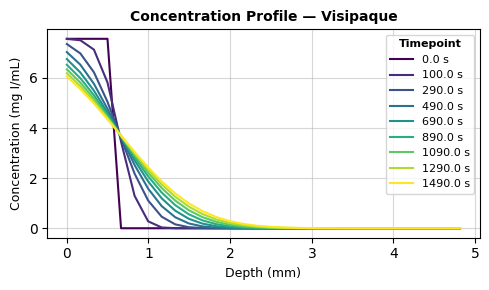

In [372]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc_sim[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)


ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

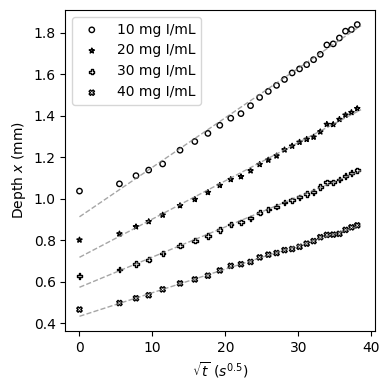

In [373]:
fig, ax = plt.subplots(figsize = (4, 4))
cats = [str(c) + " mg I /mL" for c in c_null_list]
markers = ["o", "*", "P", "X"]

for i, r in enumerate(icd_results):
        t_front = r["t_0.5"]
        x_front = r["iso_front"]
        c_null = r["c_null"]
        intercept = r["intercept"]
        slope = r["slope"]

        ax.scatter(t_front[::3], x_front[::3], 
                marker = markers[i], 
                edgecolors = "black", 
                facecolors = "none", 
                s  = 15,
                label = f"{c_null} mg I/mL")
        ax.set_xlabel(f"$\\sqrt{{t}}$ ($s^{{0.5}}$)")
        ax.set_ylabel(f"Depth $x$ (mm)")

        # plot regression line
        x_reg = np.linspace(0, np.nanmax(t_front), len(t_front))
        y_reg = slope * x_reg + intercept
        ax.plot(x_reg, y_reg, 
                linestyle = "--",
                c = "grey",
                alpha = 0.7,
                linewidth = 1)
plt.legend()  
plt.tight_layout()
plt.show()

In [374]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df_bound = pd.DataFrame(rows)
summary_df_bound["delta_aic"] = summary_df_bound["AIC"] - summary_df_bound["AIC"].min()
summary_df_bound["delta_bic"] = summary_df_bound["BIC"] - summary_df_bound["BIC"].min()
summary_df_bound.sort_values("delta_aic")

NameError: name 'results' is not defined

# With Manual Boundary

In [ ]:
dat = import_dat(boundary = True)

conc, depth, time = [np.asarray(dat[k], dtype = float) for k in sorted(dat.keys())]
depth = depth.flatten()
time = time.flatten()

depth = depth[:25]
conc = conc[:, :25]
time = time

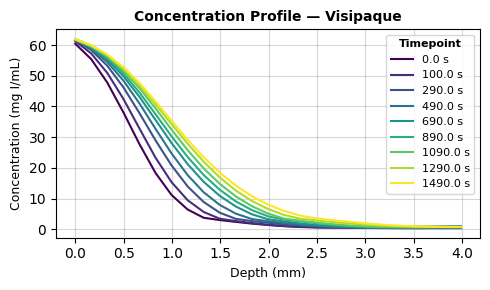

In [ ]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

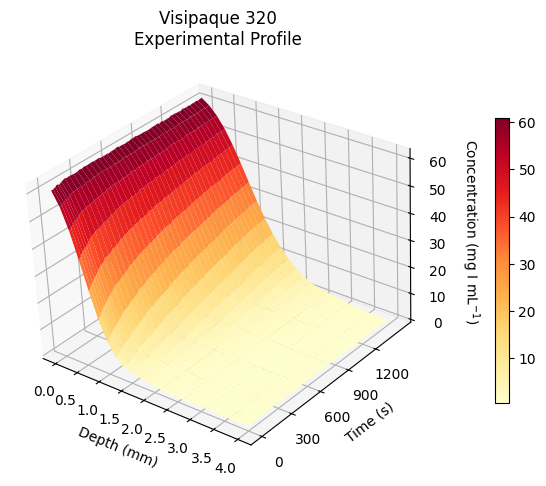

In [ ]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

In [ ]:
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [False]:
    for cs_mode in ["global", "fixed"]:
        if fit_x0:
            x0_mode = "global"
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
        else:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
print(f"# of configs: {len(configs)}")

# of configs: 2


In [ ]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [ ]:
results[0].lb_all

array([9.84855613e-04, 6.59292210e+01])

In [ ]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "D_lb": r.lb_all[1],
        "D_ub": r.ub_all[1],
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "Cs_lb": r.lb_all[2],
        "Cs_ub": r.ub_all[2],
        "x0": x0_summary,
        "x0_lb": r.lb_all[0],
        "x0_ub": r.ub_all[0]
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df = pd.DataFrame(rows)
summary_df["delta_aic"] = summary_df["AIC"] - summary_df["AIC"].min()
summary_df["delta_bic"] = summary_df["BIC"] - summary_df["BIC"].min()
summary_df.sort_values("delta_aic")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2027193068.py, line 27)

# Plotting vs experimental profile

## Free Boundary

In [ ]:
dat = import_dat(boundary = False)

depth, time, conc = [np.asarray(dat[k], dtype = float) for k in dat.keys()]
depth = depth.flatten()
time = time.flatten()

# Manually selected (initial drop -> interface, flattened)
depth = depth[12:30]
depth = depth - np.nanmin(depth)
conc = conc[:, 12:30]

In [ ]:
configs = []
cs_exp = np.nanmean(conc[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        if fit_x0:
            x0_mode = "global"
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    x0_bounds = (0, np.inf),
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
        else:
            if cs_mode == "fixed":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode,
                    cs_fixed = cs_exp
                )
                configs.append(cfg)
            elif cs_mode == "global":
                cfg = fitting.FitConfig(
                    model = "semi-infinite",
                    fit_x0 = fit_x0,
                    d_mode = d_mode,
                    cs_mode = cs_mode
                )
                configs.append(cfg)
print(f"# of configs: {len(configs)}")

# of configs: 2


In [ ]:
results = []

with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc, depth, time, cfg)
        results.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [ ]:
rows = []

for r in results:
    cfg = r.config
    d_summary = r.d_global if cfg.d_mode == "global" else np.nanmedian(r.d_per_t)
    cs_summary = r.cs_global or r.cs_fixed if cfg.cs_mode in ["global", "fixed"] else np.nanmedian(r.cs_per_t)

    if cfg.fit_x0:
        x0_summary = np.nanmedian(r.x0_per_t) if cfg.x0_mode == "per-timepoint" else r.x0_global
    else:
        x0_summary = np.nan

    rows.append({
        "model": cfg.model,
        "fit_x0": cfg.fit_x0,
        "d_mode": cfg.d_mode,
        "cs_mode": cfg.cs_mode,
        "x0_mode": cfg.x0_mode,
        "D": d_summary,
        "Cs": cs_summary if cfg.model == "semi-infinite" else cs_summary / 2,
        "x0": x0_summary,
        "R2": r.r2_global,
        "RSE_mean": np.nanmean(r.rse_per_t) if r.rse_per_t is not None else np.nan,
        "Global RSE": r.rse_global,
        "AIC": r.aic,
        "BIC": r.bic,
        "n_params": r.n_params_total
    })

summary_df_2 = pd.DataFrame(rows)
summary_df_2["delta_aic"] = summary_df_2["AIC"] - summary_df_2["AIC"].min()
summary_df_2["delta_bic"] = summary_df_2["BIC"] - summary_df_2["BIC"].min()
summary_df_2.sort_values("delta_aic")

,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
0,semi-infinite,True,global,global,global,0.000342,35.095586,1.794501e-19,0.960695,1.766812,2.023470,2032.86057,2048.677765,3,0.00000,0.000000
1,semi-infinite,True,global,fixed,global,0.000360,34.079079,1.518753e-16,0.959800,1.823413,2.045653,2063.26390,2073.808697,2,30.40333,25.130932


## Filtering data

In [ ]:
combined = pd.concat([summary_df, summary_df_bound], keys = ["False", "True"])
combined = combined.reset_index(level = 0).rename(columns = {"level_0": "boundary"})

combined = pd.concat([combined, summary_df_2], keys = ["0mm", "2mm"])
combined = combined.reset_index(level = 0).rename(columns = {"level_0": "depth_shift"})
combined = combined.reset_index(drop = True)

combined["delta_aic"] = combined["AIC"] - combined["AIC"].min()
combined = combined.sort_values("delta_aic")

In [ ]:
combined

,depth_shift,boundary,model,fit_x0,d_mode,cs_mode,x0_mode,D,Cs,x0,R2,RSE_mean,Global RSE,AIC,BIC,n_params,delta_aic,delta_bic
4,2mm,NaN,semi-infinite,True,global,global,global,0.000342,35.095586,1.794501e-19,0.960695,1.766812,2.023470,2032.860570,2048.677765,3,0.000000,0.000000
5,2mm,NaN,semi-infinite,True,global,fixed,global,0.000360,34.079079,1.518753e-16,0.959800,1.823413,2.045653,2063.263900,2073.808697,2,30.403330,25.130932
2,0mm,True,semi-infinite,True,global,global,global,0.000288,32.888158,2.008024e+00,0.977760,3.490283,4.054208,6721.823877,6739.173549,3,4688.963307,0.000000
0,0mm,False,semi-infinite,False,global,global,global,0.001021,66.780652,NaN,0.915948,5.099061,5.999467,7168.681574,7179.883379,2,5135.821005,0.000000
1,0mm,False,semi-infinite,False,global,fixed,global,0.001159,61.624955,NaN,0.909797,5.501264,6.213571,7307.942837,7313.543739,1,5275.082267,133.660360
3,0mm,True,semi-infinite,True,global,fixed,global,0.002982,64.449782,6.281681e-01,0.797592,11.343696,12.228271,12020.001692,12031.568140,2,9987.141122,5292.394591
